Episode 0: Score 120.0, Epsilon 1.0000
Episode 100: Score 100.0, Epsilon 0.9058
Episode 200: Score 110.0, Epsilon 0.8205
Episode 300: Score 80.0, Epsilon 0.7434
Episode 400: Score 70.0, Epsilon 0.6736
Episode 500: Score 80.0, Epsilon 0.6105
Episode 600: Score 100.0, Epsilon 0.5533
Episode 700: Score 430.0, Epsilon 0.5016
Episode 800: Score 250.0, Epsilon 0.4548
Training complete! Average Score: 131.7888888888889


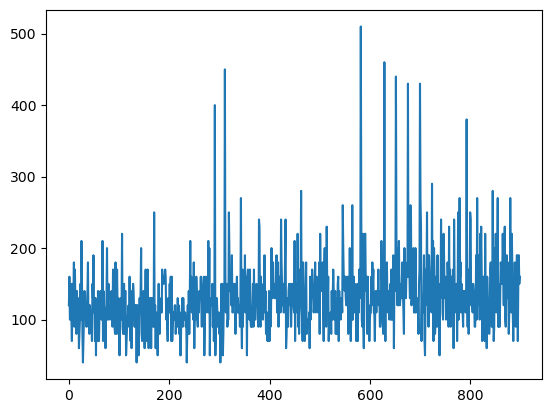

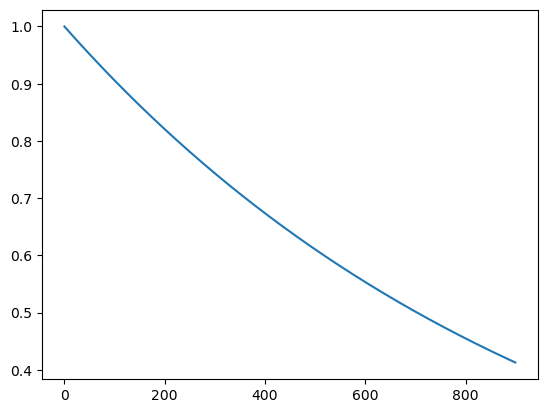

In [6]:
#%pip install gymnasium
#%pip install ale_py
#pip install opencv-python
import gymnasium as gym
import ale_py
import numpy as np
import random
import cv2
import warnings
from collections import deque
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

# Custom Frame Stacking Wrapper
class CustomFrameStack(gym.Wrapper):
    def __init__(self, env, num_stack=4):
        super().__init__(env)
        self.num_stack = num_stack
        self.frames = deque(maxlen=num_stack)

    def reset(self):
        obs, info = self.env.reset()
        obs = self._preprocess(obs)
        for _ in range(self.num_stack):
            self.frames.append(obs)
        return np.stack(self.frames, axis=-1), info

    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        obs = self._preprocess(obs)
        self.frames.append(obs)
        return np.stack(self.frames, axis=-1), reward, done, truncated, info

    def _preprocess(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (84, 84))
        return resized

# Create Atari environment
env = gym.make("ALE/MsPacman-v5", render_mode="rgb_array")
env = CustomFrameStack(env, num_stack=4)

# Initialize Q-table as a dictionary
Q = {}

def get_Q(state):
    """Return Q-values for a given state, initializing if unseen."""
    state_key = tuple(state.flatten())  # Convert state to a unique key
    if state_key not in Q:
        Q[state_key] = np.zeros(env.action_space.n)  # Initialize new states
    return Q[state_key]

# Hyperparameters
alpha = 0.7
discount_factor = 0.9
epsilon = 1
max_epsilon = 1
min_epsilon = 0.01
decay = 0.001
train_episodes = 900
max_steps = 200

training_rewards = []
epsilons = []

# Training Loop
for episode in range(train_episodes):
    state, _ = env.reset() #resetting the state at the start of each episode
    state = env._preprocess(state)  # Preprocess initial state
    total_training_rewards = 0 #reset reward

    for step in range(max_steps): #running an episode
        

        # Select action: Explore or Exploit
        exp_exp_tradeoff = random.uniform(0, 1) 
        state_key = tuple(state.flatten())  
        if state_key not in Q:
            Q[state_key] = np.zeros(env.action_space.n)  # Ensure state exists

        if exp_exp_tradeoff > epsilon:
            action = np.argmax(Q[state_key])
        else:
            action = env.action_space.sample()

        # Take action and observe result
        action = max(0, min(int(action), env.action_space.n - 1))
        new_state, reward, done, _, _ = env.step(action)
        new_state = env._preprocess(new_state)
        new_state_key = tuple(new_state.flatten())

        # Ensure new state is in Q-table
        if new_state_key not in Q:
            Q[new_state_key] = np.zeros(env.action_space.n)

        # Update Q-table using Q-learning update
        Q[state_key][action] = Q[state_key][action] + alpha * (
            reward + discount_factor * np.max(Q[new_state_key]) - Q[state_key][action]
        )

        total_training_rewards += reward
        state = new_state

        if done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay * episode)

    training_rewards.append(total_training_rewards) #store reward
    epsilons.append(epsilon)

    if episode % 100 == 0:
        print(f"Episode {episode}: Score {total_training_rewards}, Epsilon {epsilon:.4f}")

print("Training complete! Average Score:", sum(training_rewards) / train_episodes)


x = range(train_episodes)
plt.plot(x, training_rewards)#plotting training rewards over all episodes
plt.show()
plt.plot(x, epsilons)
plt.show()


In [1]:
x = range(train_episodes)
plt.plot(x, training_rewards) #plotting training rewards over all episodes
plt.show()

NameError: name 'train_episodes' is not defined

In [ ]:
import gymnasium as gym
import ale_py
import numpy as np
import random
import cv2
import warnings
from collections import deque
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

# Custom Frame Stacking Wrapper
class CustomFrameStack(gym.Wrapper):
    def __init__(self, env, num_stack=4):
        super().__init__(env)
        self.num_stack = num_stack
        self.frames = deque(maxlen=num_stack)

    def reset(self):
        obs, info = self.env.reset()
        obs = self._preprocess(obs)
        for _ in range(self.num_stack):
            self.frames.append(obs)
        return np.stack(self.frames, axis=-1), info

    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        obs = self._preprocess(obs)
        self.frames.append(obs)
        return np.stack(self.frames, axis=-1), reward, done, truncated, info

    def _preprocess(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (84, 84))
        return resized

# Create Atari environment
env = gym.make("ALE/MsPacman-v5", render_mode="rgb_array")
env = CustomFrameStack(env, num_stack=4)

# Initialize Q-table as a dictionary
Q = {}

def get_Q(state):
    """Return Q-values for a given state, initializing if unseen."""
    state_key = tuple(state.flatten())  # Convert state to a unique key
    if state_key not in Q:
        Q[state_key] = np.zeros(env.action_space.n)  # Initialize new states
    return Q[state_key]

# Hyperparameters
alpha = 0.7
discount_factor = 0.9
epsilon = 1
max_epsilon = 1
min_epsilon = 0.01
decay = 0.001
train_episodes = 1000
max_steps = 200

training_rewards = []
epsilons = []

# Training Loop
for episode in range(train_episodes):
    state, _ = env.reset()
    state = env._preprocess(state)  # Preprocess initial state
    total_training_rewards = 0

    for step in range(max_steps):
        exp_exp_tradeoff = random.uniform(0, 1)

        # Select action: Explore or Exploit
        state_key = tuple(state.flatten())  
        if state_key not in Q:
            Q[state_key] = np.zeros(env.action_space.n)  # Ensure state exists

        if exp_exp_tradeoff > epsilon:
            action = np.argmax(Q[state_key])
        else:
            action = env.action_space.sample()

        # Take action and observe result
        action = max(0, min(int(action), env.action_space.n - 1))
        new_state, reward, done, _, _ = env.step(action)
        new_state = env._preprocess(new_state)
        new_state_key = tuple(new_state.flatten())

        # Ensure new state is in Q-table
        if new_state_key not in Q:
            Q[new_state_key] = np.zeros(env.action_space.n)

        # Update Q-table using Bellman Equation
        Q[state_key][action] = Q[state_key][action] + alpha * (
            reward + discount_factor * np.max(Q[new_state_key]) - Q[state_key][action]
        )

        total_training_rewards += reward
        state = new_state

        if done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay * episode)

    training_rewards.append(total_training_rewards)
    epsilons.append(epsilon)

    if episode % 100 == 0:
        print(f"Episode {episode}: Score {total_training_rewards}, Epsilon {epsilon:.4f}")

print("Training complete! Average Score:", sum(training_rewards) / train_episodes)


x = range(train_episodes)
plt.plot(x, training_rewards)
plt.show()